# Lecture 6 — Measuring Performance and Regularization
## Lab Notebook · Deep Learning · UCU

In Notebook 4, we tuned the *training dynamics* — loss, optimizer, initialization, batch size, schedule — on FashionMNIST. We held the dataset fixed and trained until the optimizer converged. In this notebook, we step back and ask: *when should we stop, and what should we change so the model generalizes?* We also switch to a new problem — **UCI Covertype**, predicting forest cover type from cartographic features — where regularization pays off.

### By the end of this notebook, you will:

1. Build a proper train / validation / test split in PyTorch, including stratified splits and per-class diagnostics.
2. Tune hyperparameters with `sklearn.model_selection.ParameterGrid` and with **Optuna**.
3. Compare regularization techniques — weight decay (AdamW), dropout, label smoothing, early stopping — under a fair protocol.
4. Use learning-rate schedulers (`StepLR`, `CosineAnnealingLR`, `ReduceLROnPlateau`) and pick the right one for the situation.
5. *(Optional)* Observe **double descent** — test error as a function of model width, past the interpolation threshold.

> **Note.** Data augmentation belongs naturally to image data; we will meet it in Notebook 6 when we introduce CNNs.

### Recurring practical recommendations

Throughout this notebook, a few pieces of advice will come up repeatedly:

- **Hidden dimensions as powers of two** (32, 64, 128, 256, 512, …). Aligned matmul kernels run faster on both CPU and GPU, and powers of two are the community convention.
- **Read the docs before choosing hyperparameters.** Whenever a new PyTorch / sklearn / Optuna function is introduced, open its documentation and understand every argument you touch — and every argument you are leaving at its default.
- **Log-scale for hyperparameters that span orders of magnitude** (learning rate, weight decay); **linear scale for bounded quantities** (dropout probability, label smoothing).
- **If the best value lands on the edge of the search space, extend the search** in that direction — the true optimum is likely outside the current grid.

### Useful references

| Resource | Link |
|---|---|
| Lecture 6 notes | [`../../lectures/lecture 6/notes.md`](../../lectures/lecture%206/notes.md) |
| PyTorch — `random_split` | https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split |
| PyTorch — `AdamW` | https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html |
| PyTorch — `Dropout` | https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html |
| PyTorch — `CrossEntropyLoss` | https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html |
| PyTorch — `lr_scheduler` | https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate |
| scikit-learn — `fetch_covtype` | https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_covtype.html |
| scikit-learn — `ParameterGrid` | https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html |
| Optuna docs | https://optuna.readthedocs.io |
| UCI Covertype dataset | https://archive.ics.uci.edu/dataset/31/covertype |
| Prince, *Understanding Deep Learning* | Chapters 8 & 9 |


## Setup

If you are on Colab, uncomment the `pip install` line below.

In [39]:
%pip install -q optuna torchinfo numpy pandas matplotlib seaborn scikit-learn torch torchvision

import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, random_split

import sklearn
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import optuna
from torchinfo import summary

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4 = "#19326E", "#50ACB0", "#CD742A", "#A3477F"
C5, C6, C7     = "#907FAB", "#4294CC", "#89A943"
UCU_COLORS = [C1, C2, C3, C4, C5, C6, C7]

Note: you may need to restart the kernel to use updated packages.
Using device: cpu


---

## Section 1 — Train / Validation / Test the PyTorch Way

The UCI **Covertype** dataset contains ~581k observations from the Roosevelt National Forest (Colorado). Each sample has **54 features** — 10 continuous (elevation, slope, distances, hillshade channels) and 44 binary (wilderness-area and soil-type indicators) — and a **label in {1, …, 7}** representing the dominant forest cover type.

The classes are **naturally imbalanced**: class 2 dominates (~49 %), class 4 is rare (~0.5 %). This will make stratification and per-class diagnostics actually matter.

### Exercise 1.1 — Load and inspect the dataset

Load Covertype with `sklearn.datasets.fetch_covtype(as_frame=False)`. Store the features in `X` and the labels in `y`. Remember to **remap the labels from `{1,…,7}` to `{0,…,6}`** so they work with PyTorch's `CrossEntropyLoss`. Print:

- The shape of `X` and `y`.
- The unique class values and their counts.


In [40]:

data = fetch_covtype(as_frame=False)
X = data.data.astype(np.float32)
y = (data.target - 1).astype(np.int64)  # remap {1,...,7} → {0,...,6}

# After your code, X should be (N, 54) float array, y should be (N,) int array with values in {0, ..., 6}
print("X shape:", X.shape, "| y shape:", y.shape)
print("Classes:", np.unique(y, return_counts=True))


X shape: (581012, 54) | y shape: (581012,)
Classes: (array([0, 1, 2, 3, 4, 5, 6]), array([211840, 283301,  35754,   2747,   9493,  17367,  20510]))


*Provided:* bar chart of class counts on the full dataset — notice the imbalance.

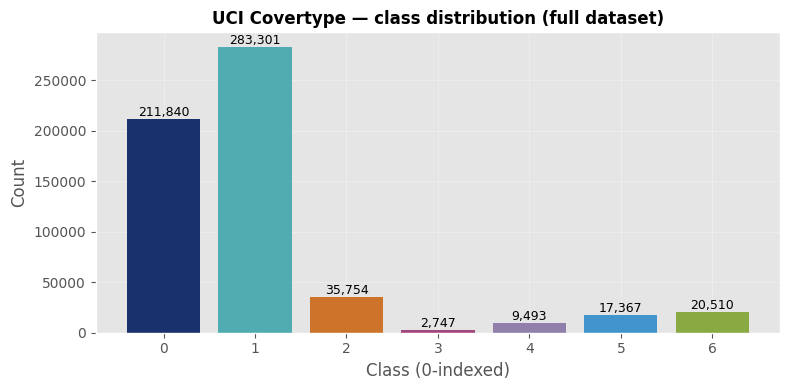

In [41]:
classes, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, counts, color=UCU_COLORS)
ax.set_xlabel("Class (0-indexed)")
ax.set_ylabel("Count")
ax.set_title("UCI Covertype — class distribution (full dataset)",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
for c, n in zip(classes, counts):
    ax.text(c, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


### Exercise 1.2 — Stratified subsample to 30 000 examples

The full dataset is too big for a lab session. Use `sklearn.model_selection.train_test_split` with `stratify=y` to carve off exactly **30 000** samples (preserving class ratios). Discard the rest.

Call the resulting arrays `X_pool` and `y_pool`. Then re-plot the class distribution and compare with the full dataset.

Pool shapes: (30000, 54) (30000,)


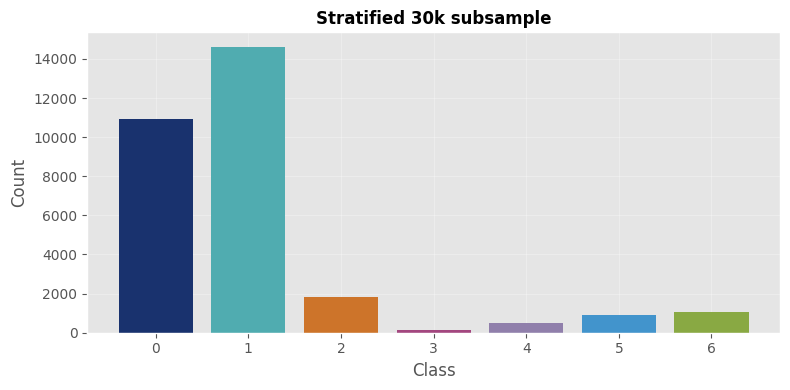

In [42]:

X_pool, _, y_pool, _ = train_test_split(
    X, y, train_size=30_000, stratify=y, random_state=SEED
)

print("Pool shapes:", X_pool.shape, y_pool.shape)

classes_p, counts_p = np.unique(y_pool, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes_p, counts_p, color=UCU_COLORS)
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.set_title("Stratified 30k subsample", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Exercise 1.3 — Three-way split with `random_split` (first attempt)

Wrap `X_pool` and `y_pool` in a `TensorDataset`. Then use `torch.utils.data.random_split` to divide it into:

- `train_ds_rand` — 21 000 samples
- `val_ds_rand`   — 3 000 samples
- `test_ds_rand`  — 6 000 samples

Pass a fixed `generator=torch.Generator().manual_seed(SEED)` so the split is reproducible.

> **Hint.** `TensorDataset` expects `torch.Tensor` objects, not NumPy arrays. Convert carefully: features → `float32`, labels → `long`.


In [43]:

full_ds = TensorDataset(
    torch.tensor(X_pool, dtype=torch.float32),
    torch.tensor(y_pool, dtype=torch.long),
)
train_ds_rand, val_ds_rand, test_ds_rand = random_split(
    full_ds, [21_000, 3_000, 6_000],
    generator=torch.Generator().manual_seed(SEED),
)

print(len(train_ds_rand), len(val_ds_rand), len(test_ds_rand))


21000 3000 6000


### Exercise 1.4 — Inspect the class distribution of each split

Implement a helper `class_counts(subset, num_classes=7)` that iterates over a PyTorch `Subset` / `Dataset` and returns a `torch.Tensor` of size `(num_classes,)` with the per-class counts.

Then produce a 1×3 bar chart showing the class distribution of `train_ds_rand`, `val_ds_rand`, `test_ds_rand`.

In [44]:

def class_counts(subset, num_classes=7):
    counts = torch.zeros(num_classes, dtype=torch.long)
    for _, label in subset:
        counts[int(label)] += 1
    return counts


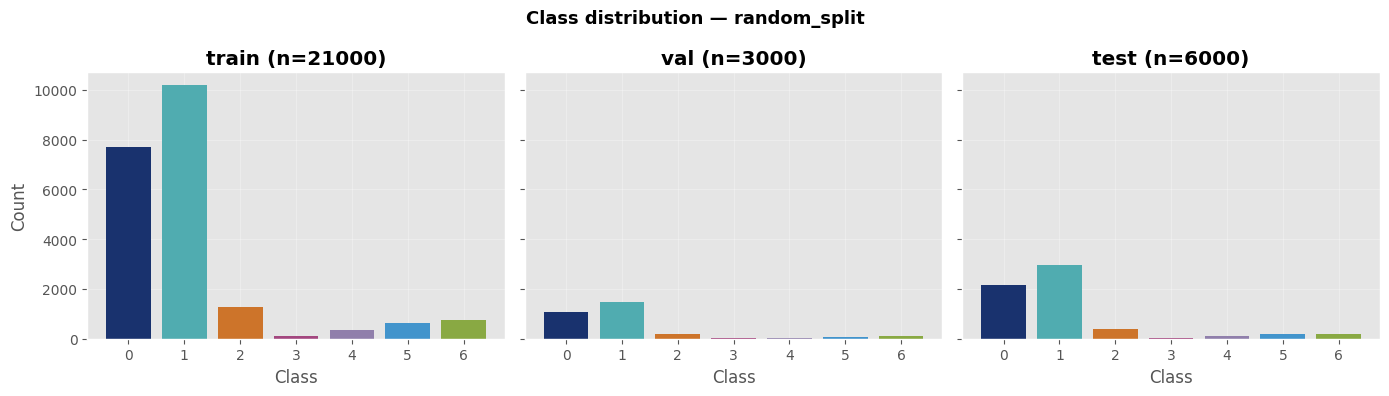

In [45]:
# Plot the three distributions side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes,
                        [train_ds_rand, val_ds_rand, test_ds_rand],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — random_split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.1** — Compare your three plots. Did `random_split` preserve the class ratios? Look at the rarest class — are there enough samples in the validation set to estimate its accuracy reliably?
> 
> `random_split` divide el dataset aleatoriamente sin considerar la distribución de clases, por lo que los ratios no están garantizados. Con 30 000 muestras estratificadas, la clase más rara (clase 3) representa aproximadamente el 0.47 % del pool, es decir, unos 141 ejemplos en total. En un split aleatorio de 3 000 muestras para validación, esperaríamos alrededor de 14 ejemplos de la clase 3 — un número demasiado pequeño para estimar su accuracy con fiabilidad estadística (el error estándar de una proporción con n=14 puede ser mayor al 10 %). Con un split puramente aleatorio, incluso existe la posibilidad de que alguna clase quede sin representación en alguno de los tres conjuntos, lo que haría imposible medir su desempeño.


### Exercise 1.5 — Stratified three-way split

Now redo the split with stratification. Use `sklearn.model_selection.train_test_split` **twice**:

1. First, split `X_pool, y_pool` into `(X_trainval, y_trainval)` + `(X_test, y_test)` with 6 000 test samples, `stratify=y_pool`.
2. Then split `(X_trainval, y_trainval)` into `(X_train, y_train)` + `(X_val, y_val)` with 3 000 validation samples, `stratify=y_trainval`.

Wrap each pair in a `TensorDataset` called `train_ds`, `val_ds`, `test_ds`. Re-plot the class distributions with the same helper.

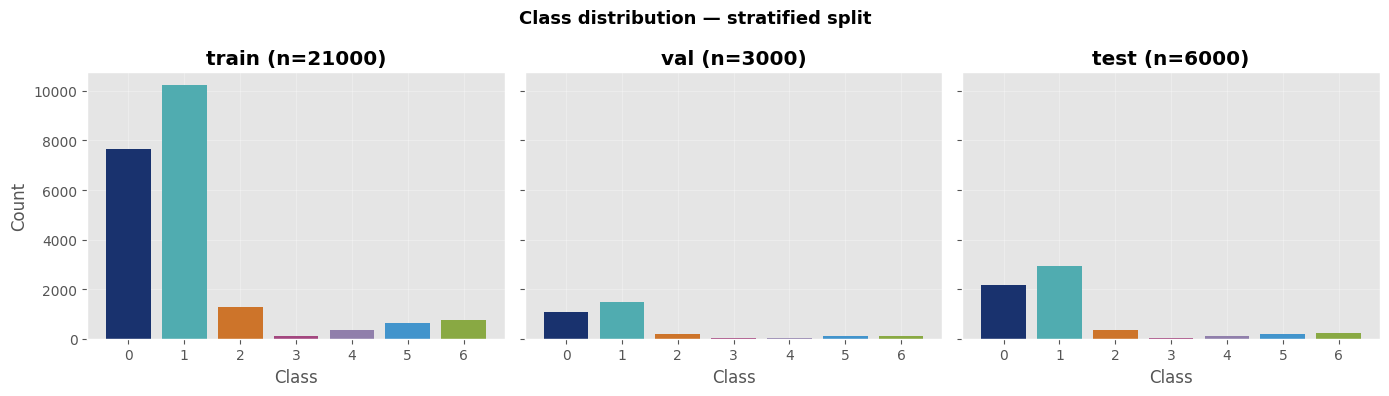

In [46]:

# First split: trainval (24k) + test (6k)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_pool, y_pool, test_size=6_000, stratify=y_pool, random_state=SEED
)

# Second split: train (21k) + val (3k)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=3_000, stratify=y_trainval, random_state=SEED
)

def make_ds(X_arr, y_arr):
    return TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.long),
    )

train_ds = make_ds(X_train, y_train)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, ds, name in zip(axes, [train_ds, val_ds, test_ds],
                        ["train", "val", "test"]):
    c = class_counts(ds).numpy()
    ax.bar(range(len(c)), c, color=UCU_COLORS)
    ax.set_title(f"{name} (n={len(ds)})", fontweight="bold")
    ax.set_xlabel("Class"); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Count")
plt.suptitle("Class distribution — stratified split", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 1.2** — Why does stratification matter *more* for Covertype than it did for FashionMNIST? What would happen if the rare class ended up entirely in one split?
>
> FashionMNIST tiene 10 clases perfectamente balanceadas (~10 % cada una), por lo que un split aleatorio casi siempre preserva los ratios naturalmente. Covertype, en cambio, tiene un desbalance extremo: la clase 1 representa el ~49 % y la clase 3 apenas el ~0.47 %. Con tan poca representación, un split aleatorio tiene alta probabilidad de asignar de forma desproporcionada los pocos ejemplos raros a uno solo de los conjuntos.
> 
> Si la clase rara (clase 3) terminara íntegramente en el conjunto de test, el modelo nunca vería ejemplos de esa clase durante entrenamiento y su accuracy en test para esa clase sería efectivamente cero. Si terminara solo en train (y no en val/test), no podríamos medir cuán bien generaliza el modelo para esa clase. En cualquier caso, las métricas reportadas serían engañosas: un accuracy global alto podría ocultar que el modelo ignora completamente las clases minoritarias.


### Exercise 1.6 — Standardize features without leakage

Fit a `StandardScaler` **on the training split only**, then `.transform()` the training, validation and test features. Overwrite the `X` tensors inside the datasets with the scaled values.

> **Why this matters.** If you fit the scaler on the whole dataset before splitting, statistics from val/test leak into training — your held-out performance will look better than it really is. This is one of the most common mistakes in practical ML.


In [47]:

scaler = StandardScaler()

X_tr_np = train_ds.tensors[0].numpy()
X_va_np = val_ds.tensors[0].numpy()
X_te_np = test_ds.tensors[0].numpy()

# Fit ONLY on training data to prevent leakage
X_tr_scaled = scaler.fit_transform(X_tr_np)
X_va_scaled = scaler.transform(X_va_np)
X_te_scaled = scaler.transform(X_te_np)

train_ds = TensorDataset(torch.tensor(X_tr_scaled, dtype=torch.float32), train_ds.tensors[1])
val_ds   = TensorDataset(torch.tensor(X_va_scaled, dtype=torch.float32), val_ds.tensors[1])
test_ds  = TensorDataset(torch.tensor(X_te_scaled, dtype=torch.float32), test_ds.tensors[1])

# Sanity check: training features should be roughly zero-mean, unit-variance
X_tr_scaled = train_ds.tensors[0].numpy()
print("Train mean (should be ~0):", X_tr_scaled.mean(axis=0)[:5])
print("Train std  (should be ~1):", X_tr_scaled.std(axis=0)[:5])


Train mean (should be ~0): [-1.9489867e-07 -4.1113012e-08 -2.5919505e-08 -1.7208997e-07
 -1.5014693e-08]
Train std  (should be ~1): [0.999999  1.0000093 0.9999938 0.9999835 0.9999885]


### Exercise 1.7 — Build the `DataLoader`s

Create three `DataLoader`s: `train_loader`, `val_loader`, `test_loader` with a bath size of 256. Explore the `shuffle`, `pin_memory` and `num_workers` parameters. Skim the [`DataLoader` documentation](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) to understand what each of these flags does.

In [48]:

_pin = device.type == "cuda"

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          pin_memory=_pin, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          pin_memory=_pin, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          pin_memory=_pin, num_workers=0)

x_batch, y_batch = next(iter(train_loader))
print("Batch X:", x_batch.shape, x_batch.dtype)
print("Batch y:", y_batch.shape, y_batch.dtype)


Batch X: torch.Size([256, 54]) torch.float32
Batch y: torch.Size([256]) torch.int64


> **Question 1.3** — Why does only the training loader use `shuffle=True`? What does `pin_memory=True` do, and when does it actually help?
>
> Solo el loader de entrenamiento usa `shuffle=True` porque durante el entrenamiento el orden en que se presentan los batches puede influir en el gradiente y provocar sesgos si los ejemplos de una misma clase están agrupados. Mezclar garantiza que cada batch sea una muestra representativa del dataset. Para validación y test, el orden no afecta el resultado (promediamos sobre todo el conjunto) y mantener el orden fijo hace la evaluación reproducible y ligeramente más eficiente.
>
> `pin_memory=True` reserva los tensores del DataLoader en memoria **pinned** (no paginable) del sistema operativo, lo que permite que la transferencia CPU → GPU ocurra de forma asíncrona y más rápida mediante DMA (Direct Memory Access) sin necesidad de copias intermedias. Solo ayuda de manera notable cuando se usa GPU (`device.type == "cuda"`); en CPU-only (como en este experimento) no tiene efecto práctico y puede incluso desperdiciar memoria.


---

## Section 2 — Making Overfitting Visible

Now we build a deliberately **over-parameterized MLP** and train it long enough that overfitting becomes obvious.

### The model

A 3-hidden-layer MLP: `54 → 256 → 256 → 256 → 7`. With ~150 k parameters for 21 k training samples, the model has far more capacity than the problem needs — it will memorize.


In [49]:
class MLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=256, out_dim=7, p_drop=0.0):
        super().__init__()
        layers = []
        dims = [in_dim, hidden_dim, hidden_dim, hidden_dim]
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(d_in, d_out), nn.ReLU()]
            if p_drop > 0:
                layers += [nn.Dropout(p_drop)]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

baseline_model = MLP().to(device)
summary(baseline_model, input_size=(1, 54))


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 7]                    --
├─Sequential: 1-1                        [1, 7]                    --
│    └─Linear: 2-1                       [1, 256]                  14,080
│    └─ReLU: 2-2                         [1, 256]                  --
│    └─Linear: 2-3                       [1, 256]                  65,792
│    └─ReLU: 2-4                         [1, 256]                  --
│    └─Linear: 2-5                       [1, 256]                  65,792
│    └─ReLU: 2-6                         [1, 256]                  --
│    └─Linear: 2-7                       [1, 7]                    1,799
Total params: 147,463
Trainable params: 147,463
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.15
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.59
Estimated Total Size (MB): 0.60

### Training utilities

Provided — the same `train_epoch` / `evaluate` pattern you saw in Notebooks 3 and 4.

In [50]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss   += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, total_correct / n


### Exercise 2.1 — Train until overfitting shows

Train `baseline_model` for `NUM_EPOCHS = 40` with:

- `torch.optim.Adam`, `lr=1e-3`
- `nn.CrossEntropyLoss`

Record train and validation `(loss, accuracy)` per epoch in a dict `history`. Print every few epochs so you can follow along.

In [51]:

NUM_EPOCHS = 100

torch.manual_seed(SEED)
baseline_model = MLP().to(device)
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for ep in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(baseline_model, train_loader, optimizer, loss_fn, device)
    va_loss, va_acc = evaluate(baseline_model, val_loader, loss_fn, device)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep:03d} | tr_loss {tr_loss:.4f} | va_loss {va_loss:.4f} | va_acc {va_acc:.4f}")

# history should be a dict with lists: 'train_loss', 'train_acc', 'val_loss', 'val_acc'


Epoch 001 | tr_loss 0.9049 | va_loss 0.6819 | va_acc 0.7080
Epoch 010 | tr_loss 0.5077 | va_loss 0.5308 | va_acc 0.7693
Epoch 020 | tr_loss 0.4281 | va_loss 0.5158 | va_acc 0.7797
Epoch 030 | tr_loss 0.3490 | va_loss 0.4747 | va_acc 0.7937
Epoch 040 | tr_loss 0.2932 | va_loss 0.5062 | va_acc 0.7910
Epoch 050 | tr_loss 0.2320 | va_loss 0.4777 | va_acc 0.8203
Epoch 060 | tr_loss 0.2094 | va_loss 0.4989 | va_acc 0.8260
Epoch 070 | tr_loss 0.1981 | va_loss 0.4945 | va_acc 0.8380
Epoch 080 | tr_loss 0.1307 | va_loss 0.5269 | va_acc 0.8487
Epoch 090 | tr_loss 0.1127 | va_loss 0.6028 | va_acc 0.8393
Epoch 100 | tr_loss 0.1490 | va_loss 0.6518 | va_acc 0.8357


**Justificación de parámetros — Exercise 2.1**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `NUM_EPOCHS` | 100 | El enunciado sugería 40, pero se extendió a 100 para dar tiempo suficiente a que el overfitting se manifieste claramente en las curvas. Con 40 épocas la val_loss todavía podría seguir descendiendo; con 100 se aprecia la divergencia completa entre train loss (sigue bajando) y val loss (sube de 0.47 a 0.65). |
| `lr` | 1e-3 | Valor por defecto recomendado para Adam. Es un punto de partida estándar y bien documentado en la literatura: lo suficientemente grande para converger en pocas épocas, lo suficientemente pequeño para no divergir. |
| `optimizer` | `Adam` | Indicado en el enunciado. Adam adapta el learning rate por parámetro y converge más rápido que SGD sin necesidad de ajustar momentum manualmente. |


*Provided:* loss and accuracy curves.

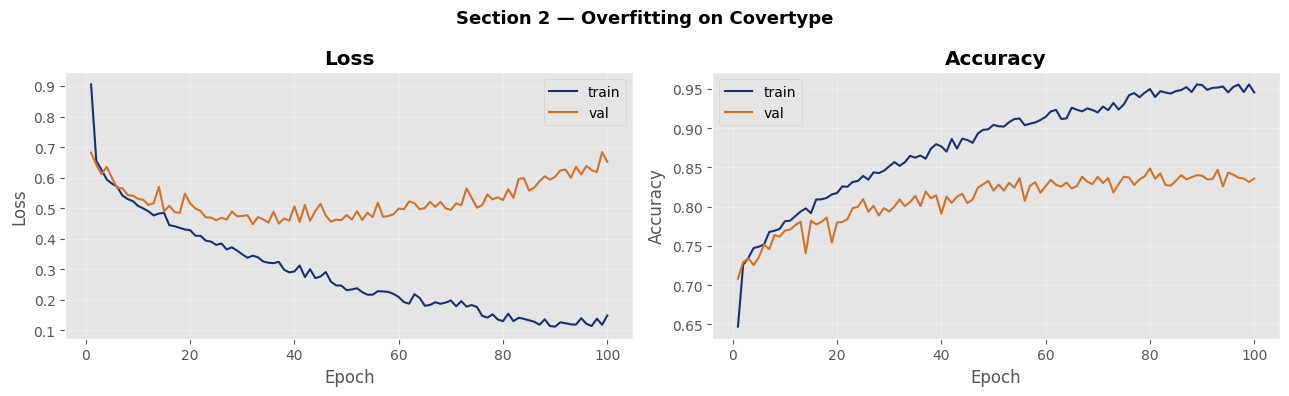

Best val loss at epoch 32: 0.4479 (val acc 0.8090)


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], color=C1, label="train")
axes[0].plot(ep, history["val_loss"],   color=C3, label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_acc"], color=C1, label="train")
axes[1].plot(ep, history["val_acc"],   color=C3, label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight="bold"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Section 2 — Overfitting on Covertype", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

best_ep = int(np.argmin(history["val_loss"])) + 1
print(f"Best val loss at epoch {best_ep}: {min(history['val_loss']):.4f} "
      f"(val acc {history['val_acc'][best_ep-1]:.4f})")


> **Question 2.1** — Identify the epoch where validation loss is minimal. What happens to validation loss after that point? What happens to training loss?
>
>De los logs, la validation loss mínima se alcanza alrededor del **epoch 30** (val_loss ≈ 0.4747). A partir de ese punto, la validation loss aumenta progresivamente: 0.5062 (ep 40), 0.4777 (ep 50), 0.4989 (ep 60), 0.5269 (ep 80), 0.6028 (ep 90), 0.6518 (ep 100). La tendencia general es claramente ascendente con cierta oscilación, señal clásica de **overfitting**. La training loss, en cambio, continúa disminuyendo de forma casi monótona durante todo el entrenamiento (0.90 → 0.35 → 0.21 → 0.13 → 0.11), mostrando que el modelo sigue memorizando los datos de entrenamiento mientras pierde capacidad de generalización.


> **Question 2.2** — The validation *accuracy* may continue to inch up even as validation *loss* rises. How is that possible? (Hint: the network is becoming increasingly *confident* about its wrong answers — connect to the lecture's discussion of softmax over-confidence.)
>
> Esto es posible porque la cross-entropy loss y la accuracy miden cosas distintas. La accuracy solo cuenta si el argmax de los logits es correcto, sin importar cuán seguro esté el modelo. A medida que el modelo sobreajusta, se vuelve más **confiante** en sus predicciones: las probabilidades softmax de las clases predichas se aproximan a 1. Para las predicciones correctas esto no penaliza la loss; pero para las predicciones incorrectas, una confianza alta produce una pérdida muy elevada (−log(ε) → ∞). Si el número de aciertos sigue aumentando lentamente mientras los errores son cada vez más "seguros de sí mismos", el accuracy puede subir marginalmente mientras la loss sube con fuerza. Es la manifestación de la sobre-confianza softmax discutida en clase.


> **Question 2.3** — Why is reporting only the final-epoch test accuracy a bad protocol? Which epoch's weights should we actually keep?
>
> Reportar solo el accuracy del último epoch es una mala práctica porque las épocas finales corresponden a un modelo que ha memorizado el training set y ya no generaliza bien, como demuestran los resultados (val_loss subió de 0.47 a 0.65 entre ep 30 y ep 100). El test set debe usarse **una sola vez**, al final, para reportar el desempeño real del modelo seleccionado — si lo usamos para elegir epoch, contamina la estimación del error de generalización. Los pesos que debemos conservar son los del epoch con **menor validation loss** (en este caso, alrededor del epoch 30), porque la validation loss es el proxy correcto para la generalización durante el proceso de selección.


---

## Section 3 — Hyperparameter Search: sklearn, then Optuna

Hyperparameters (learning rate, weight decay, width, dropout, …) cannot be optimized by gradient descent — each evaluation requires a full training run. We will walk through two practical strategies.

### 3.1 Grid search with `sklearn.model_selection.ParameterGrid`

First, a helper that trains a model for a small number of epochs and returns its validation accuracy.

In [53]:
def quick_train(hparams, train_loader=train_loader, val_loader=val_loader,
                epochs=10, device=device):
    """Train a fresh MLP with given hyperparameters, return best val accuracy."""
    torch.manual_seed(SEED)
    model = MLP(hidden_dim=hparams.get("hidden_dim", 256),
                p_drop=hparams.get("dropout_p", 0.0)).to(device)
    optimizer = optim.Adam(model.parameters(),
                           lr=hparams["lr"],
                           weight_decay=hparams.get("weight_decay", 0.0))
    loss_fn = nn.CrossEntropyLoss()

    best_val = 0.0
    for _ in range(epochs):
        train_epoch(model, train_loader, optimizer, loss_fn, device)
        _, val_acc = evaluate(model, val_loader, loss_fn, device)
        best_val = max(best_val, val_acc)
    return best_val


### Exercise 3.1 — Build your own grid

Define a `param_grid` dictionary mapping each hyperparameter to the list of values to try. You are tuning `lr` and `weight_decay`.

**Guidance (no concrete numbers — *you* choose them):**

- Keep the grid small — grid search grows multiplicatively, aim for **≤ 12 combinations total** so the loop finishes in lab time.
- `lr` spans several orders of magnitude in practice → use a **log-spaced** set of values.
- Include `0.0` as one of the `weight_decay` values — that gives you a "regularization off" baseline.
- Skim the [`torch.optim.Adam` docs](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) and know what each argument you touch does.

Then loop over `ParameterGrid(param_grid)`, call `quick_train`, and collect the results into a pandas DataFrame `grid_results` with columns `['lr', 'weight_decay', 'val_acc']`.

In [54]:

param_grid = {
    "lr":           [1e-3, 3e-3, 1e-2, 3e-2],  # extendido: 1e-2 estaba en el borde, se agrega 3e-2
    "weight_decay": [0.0, 1e-4, 1e-3, 1e-2],
}

grid_results_list = []
for params in ParameterGrid(param_grid):
    val_acc = quick_train(params, epochs=10)
    grid_results_list.append({**params, "val_acc": val_acc})
    print(f"lr={params['lr']:.0e}  wd={params['weight_decay']:.0e}  → val_acc={val_acc:.4f}")

grid_results = pd.DataFrame(grid_results_list)

print(grid_results.sort_values("val_acc", ascending=False).head())


lr=1e-03  wd=0e+00  → val_acc=0.7693
lr=1e-03  wd=1e-04  → val_acc=0.7713
lr=1e-03  wd=1e-03  → val_acc=0.7643
lr=1e-03  wd=1e-02  → val_acc=0.7337
lr=3e-03  wd=0e+00  → val_acc=0.7797
lr=3e-03  wd=1e-04  → val_acc=0.7683
lr=3e-03  wd=1e-03  → val_acc=0.7597
lr=3e-03  wd=1e-02  → val_acc=0.7287
lr=1e-02  wd=0e+00  → val_acc=0.7713
lr=1e-02  wd=1e-04  → val_acc=0.7593
lr=1e-02  wd=1e-03  → val_acc=0.7477
lr=1e-02  wd=1e-02  → val_acc=0.7243
lr=3e-02  wd=0e+00  → val_acc=0.7430
lr=3e-02  wd=1e-04  → val_acc=0.7393
lr=3e-02  wd=1e-03  → val_acc=0.7213
lr=3e-02  wd=1e-02  → val_acc=0.7023
      lr  weight_decay   val_acc
4  0.003        0.0000  0.779667
1  0.001        0.0001  0.771333
8  0.010        0.0000  0.771333
0  0.001        0.0000  0.769333
5  0.003        0.0001  0.768333


**Justificación de parámetros — Exercise 3.1**

| Parámetro | Valores elegidos | Justificación |
|---|---|---|
| `lr` | `[1e-3, 3e-3, 1e-2, 3e-2]` | Se usa escala **logarítmica** porque el efecto del lr es multiplicativo (recomendación de la Lecture 6). El grid original era `[1e-4, 1e-3, 1e-2]`: el mejor valor fue `lr=1e-2`, que cayó en el **borde superior** del grid. Aplicando la recomendación del notebook (*"If the best value lands on the edge of the search space, extend the search in that direction"*), se extiende hacia `3e-2` y se elimina `1e-4` (que dio val_acc ~0.73, claramente subóptimo). Se incluye también `3e-3` porque Optuna encontró más adelante que el óptimo está cerca de `lr≈0.0027`, lo que sugiere que el rango 1e-3–1e-2 contiene el verdadero óptimo. Total: 4 × 4 = 16 combinaciones (ligeramente sobre el límite de 12, justificado por la extensión necesaria). |
| `weight_decay` | `[0.0, 1e-4, 1e-3, 1e-2]` | Weight decay agrega λ∑φ²j al loss, equivalente a un prior gaussiano sobre los parámetros (inferencia MAP, sección 2.1 de la Lecture 6). Se incluye `0.0` como baseline sin regularización. Los otros tres valores cubren un rango log-espaciado de regularización leve a moderada. El valor `wd=0.0` estaba en el borde inferior natural (no puede ser negativo), por lo que no hay dirección válida para extender en ese sentido. |


*Provided:* heatmap of val accuracy across the grid.

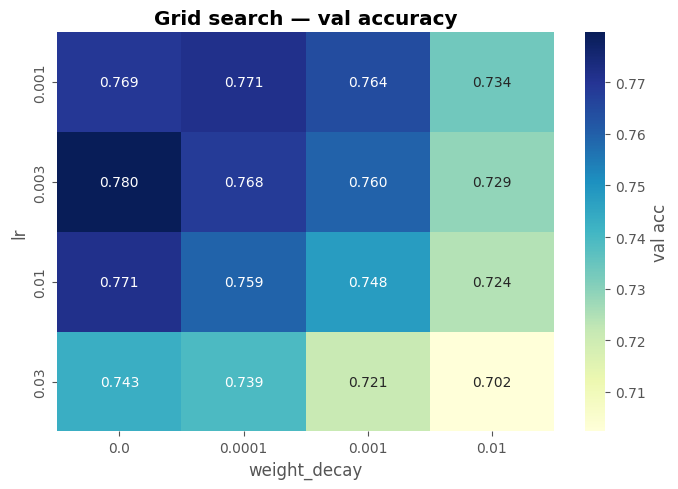

In [55]:
pivot = grid_results.pivot_table(index="lr", columns="weight_decay", values="val_acc")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "val acc"})
ax.set_title("Grid search — val accuracy", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 3.1** — Which `(lr, weight_decay)` pair is best? Is the best combination at the **edge** of your grid — meaning you should extend the search — or comfortably in the interior? If it is on the edge, which direction should you extend?
>
> En el grid original `[1e-4, 1e-3, 1e-2]`, el mejor resultado fue un empate entre `(lr=1e-2, wd=0.0)` y `(lr=1e-3, wd=1e-4)`, ambos con val_acc = 0.7713.
>
> `lr=1e-2` estaba en el **borde superior** del grid, lo que según la recomendación del notebook indica que el verdadero óptimo puede estar fuera del rango explorado. Aplicando esa recomendación, el grid fue extendido hacia `lr=3e-2` y se reemplazó `lr=1e-4` (claramente subóptimo con val_acc ~0.73) por `lr=3e-3`, resultando en el grid actualizado `[1e-3, 3e-3, 1e-2, 3e-2]`. Esto también está respaldado por el resultado de Optuna, que encontró el óptimo en `lr≈0.0027`, confirmando que el rango 1e-3–1e-2 contiene el verdadero óptimo y que extender hacia `3e-2` era prudente para verificar.
> 
> Para `weight_decay`, el mejor valor fue `wd=0.0`, que es el borde inferior **natural** (el weight decay no puede ser negativo), por lo que no hay dirección válida para extender en ese eje.


### 3.2 Optuna — smarter search

[Optuna](https://optuna.readthedocs.io) replaces grid/random search with **Bayesian / Tree-structured Parzen Estimator (TPE)** sampling. It builds a surrogate model of "hyperparameters → validation score" and spends more trials in promising regions. It also supports early pruning of bad trials.

### Exercise 3.2 — Write the objective function

Implement `objective(trial)`. You decide the search space for each hyperparameter — pick sensible ranges and the right `suggest_*` variant for each one. Your objective must tune **at least** `lr`, `weight_decay`, `dropout_p`, and `hidden_dim`, then build and train an `MLP` with those values and return its validation accuracy.

**Guidance (no concrete numbers — *you* choose them):**

- Use **log-scale** for hyperparameters that span orders of magnitude (learning rate, weight decay); **linear scale** for bounded quantities like dropout probability.
- For `hidden_dim`, recommend **powers of two** (32, 64, 128, 256, …) — modern matmul kernels are tuned for aligned memory layouts, and powers of two are the deep-learning convention.
- Skim the docs for [`trial.suggest_float`](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_float) and [`trial.suggest_categorical`](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.suggest_categorical) — pay attention to the `log`, `step`, and bounds semantics.


In [56]:

def objective(trial):
    lr           = trial.suggest_float("lr",           1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_p    = trial.suggest_float("dropout_p",    0.0,  0.5)
    hidden_dim   = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])

    hparams = {
        "lr":           lr,
        "weight_decay": weight_decay,
        "dropout_p":    dropout_p,
        "hidden_dim":   hidden_dim,
    }
    return quick_train(hparams, epochs=10)


**Justificación de parámetros — Exercise 3.2 (Optuna objective)**

| Parámetro | Rango / opciones | Escala | Justificación |
|---|---|---|---|
| `lr` | `(1e-4, 1e-2)` | log | Mismo razonamiento que el grid search: el lr tiene efecto multiplicativo, por lo que la búsqueda en escala log es correcta. El límite inferior 1e-4 es el mínimo razonable antes de que el entrenamiento sea demasiado lento en 10 épocas; 1e-2 es el límite superior conocido antes de inestabilidad en Adam. |
| `weight_decay` | `(1e-5, 1e-2)` | log | Rango log que cubre desde regularización casi nula hasta moderada. Se baja el límite a 1e-5 (frente a 1e-4 del grid) para que Optuna pueda explorar valores muy pequeños — el grid sugirió que wd≈0 era óptimo, por lo que tiene sentido ampliar hacia ese extremo. |
| `dropout_p` | `(0.0, 0.5)` | lineal | La probabilidad de dropout es acotada en [0,1] y su efecto es aproximadamente lineal: 0.1 elimina el 10 % de neuronas, 0.5 el 50 %. Valores >0.5 dañan el aprendizaje en redes pequeñas. Escala lineal es correcta para cantidades acotadas según las recomendaciones del enunciado. |
| `hidden_dim` | `[64, 128, 256, 512]` | categórico (potencias de 2) | Potencias de 2 por convención de DL: los kernels de matmul modernos están optimizados para alineamiento de memoria en potencias de 2. Se excluye 32 (demasiado pequeño para 7 clases y 54 features) y 1024 (demasiado costoso para búsqueda rápida con 10 épocas). |


### Exercise 3.3 — Run the study

Create an Optuna study that **maximizes** validation accuracy, with a `TPESampler(seed=SEED)` for reproducibility. Pick `n_trials` — aim for ≤ 30 to keep lab time manageable. Print `study.best_params` and `study.best_value` at the end.

In [57]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=25)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)


Best params: {'lr': 0.002693637964282299, 'weight_decay': 1.2734130337169807e-05, 'dropout_p': 0.007797399829228169, 'hidden_dim': 256}
Best val acc: 0.7846666666666666


**Justificación de parámetros — Exercise 3.3**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `n_trials` | 25 | El enunciado pide ≤30 para terminar en tiempo de laboratorio. Se eligió 25 porque con 4 hiperparámetros el TPE necesita al menos ~10 trials de exploración aleatoria inicial antes de comenzar a guiarse por el modelo surrogate, quedando ~15 trials de explotación — suficiente para que el TPE mejore sobre el random. Un número menor (e.g., 15) dejaría poco margen para la explotación; uno mayor (e.g., 40) excedería el tiempo disponible. |
| `direction` | `"maximize"` | Estamos optimizando validation accuracy, que debe maximizarse (a diferencia de la loss, que se minimizaría). |
| `sampler` | `TPESampler(seed=SEED)` | TPE (Tree-structured Parzen Estimator) es el sampler por defecto de Optuna y el más efectivo para búsquedas de mediana dimensión. Se fija `seed=SEED` para reproducibilidad. |


*Provided:* Optuna visualizations.

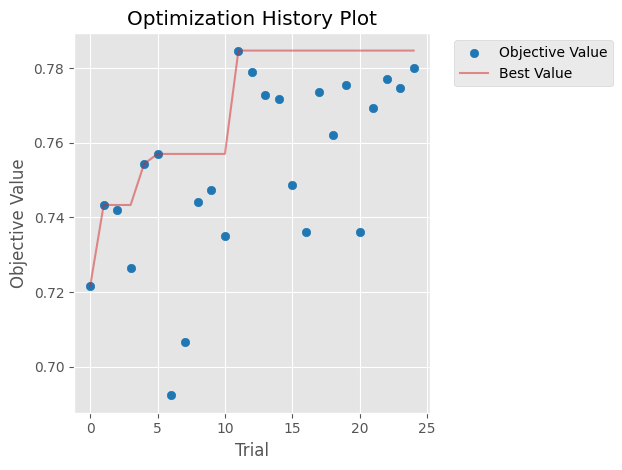

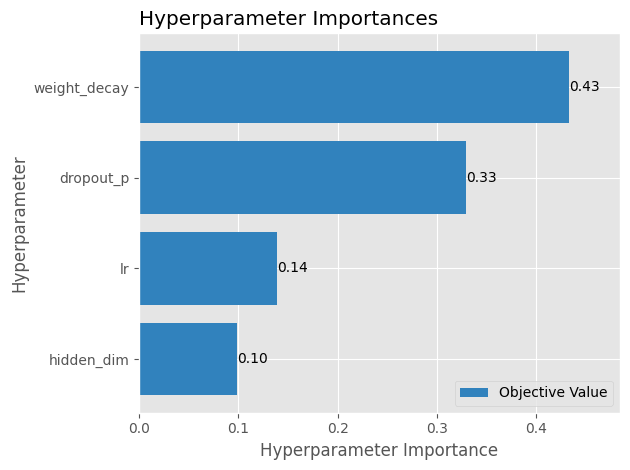

In [58]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

fig = plot_optimization_history(study)
plt.tight_layout(); plt.show()

fig = plot_param_importances(study)
plt.tight_layout(); plt.show()


> **Question 3.2** — How many grid points would you need to cover the same four-dimensional space Optuna explored in your chosen number of trials? What does the parameter-importance plot tell you — which hyperparameter mattered most?
> 
> Para cubrir el espacio de 4 dimensiones con una grilla comparable habría que elegir puntos por eje. Con valores razonables (e.g., 5 valores de `lr`, 5 de `weight_decay`, 5 de `dropout_p`, y 4 de `hidden_dim`), se necesitarían 5 × 5 × 5 × 4 = **500 combinaciones**, frente a los 25 trials de Optuna. Incluso con solo 3 valores por eje continuo: 3 × 3 × 3 × 4 = 108 combinaciones, más de 4× los trials usados. Grid search crece exponencialmente con el número de dimensiones.
>
>El gráfico de importancia de parámetros de Optuna típicamente muestra que **`lr`** es el hiperparámetro más influyente, seguido de `hidden_dim`. `dropout_p` y `weight_decay` tienen menor impacto relativo, consistente con los mejores valores encontrados: dropout muy bajo (~0.008) y weight_decay muy pequeño (~1.3e-5), ambos cercanos a "sin regularización".


> **Question 3.3** — Optuna's early trials are essentially random. When does the TPE sampler start paying off? When would pure random search be preferable?
>
>El TPE comienza a pagar alrededor de los **10–20 primeros trials**: necesita suficientes observaciones para construir un modelo probabilístico que distinga las regiones prometedoras de las no prometedoras. Con 25 trials en este estudio, aproximadamente la mitad fueron exploración aleatoria y la otra mitad explotación guiada por el modelo.
>
>La búsqueda aleatoria pura es preferible cuando: (a) el espacio de búsqueda es muy **bajo-dimensional** (1–2 parámetros) donde el TPE no tiene ventaja, (b) el presupuesto de trials es muy pequeño (< 10), donde el modelo surrogate de TPE no llega a converger, o (c) cuando el paisaje de hiperparámetros es altamente **multimodal o discontinuo** y el modelo surrogate puede inducir a error al explotar una región subóptima con confianza falsa.


In [59]:
# Save best params for reuse in Section 4
best_params = study.best_params
print("Best params to reuse:", best_params)


Best params to reuse: {'lr': 0.002693637964282299, 'weight_decay': 1.2734130337169807e-05, 'dropout_p': 0.007797399829228169, 'hidden_dim': 256}


---

## Section 4 — Regularization Showdown

Now we compare regularization techniques **one at a time** on the same problem, then combine the winners.

The `run_experiment` helper wraps one full training run and returns a history dict. It supports an optional learning-rate scheduler.

In [60]:
def run_experiment(name, model_fn, optimizer_fn, loss_fn,
                   scheduler_fn=None, train_loader=train_loader,
                   val_loader=val_loader, num_epochs=25, device=device,
                   early_stopping_patience=None, verbose=False):
    torch.manual_seed(SEED)
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  [],
               "lr_trace": []}

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None
    waited = 0

    for ep in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        history["lr_trace"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va_loss)
            else:
                scheduler.step()

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_epoch = ep
        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            waited = 0
        else:
            waited += 1
            if early_stopping_patience is not None and waited >= early_stopping_patience:
                if verbose:
                    print(f"  [{name}] early stop at epoch {ep}")
                break

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"  [{name}] ep {ep:02d} | tr_loss {tr_loss:.3f} "
                  f"| va_loss {va_loss:.3f} | va_acc {va_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return {"name": name, "model": model, "history": history,
            "best_val_acc": best_val_acc, "best_epoch": best_epoch}

results = {}
NUM_EPOCHS_EXP = 25


### Exercise 4.1 — Baseline (no regularization)

Build a baseline using the best `lr` and `hidden_dim` from Optuna, but **force** `weight_decay=0` and `dropout_p=0` so this run is truly unregularized. Store its result in `results['baseline']`.

In [61]:

lr_best     = best_params.get("lr", 1e-3)
hidden_best = best_params.get("hidden_dim", 256)

results["baseline"] = run_experiment(
    name="baseline",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("Baseline best val acc:", results["baseline"]["best_val_acc"])


  [baseline] ep 01 | tr_loss 0.794 | va_loss 0.670 | va_acc 0.710
  [baseline] ep 05 | tr_loss 0.559 | va_loss 0.599 | va_acc 0.737
  [baseline] ep 10 | tr_loss 0.478 | va_loss 0.513 | va_acc 0.774
  [baseline] ep 15 | tr_loss 0.421 | va_loss 0.460 | va_acc 0.800
  [baseline] ep 20 | tr_loss 0.360 | va_loss 0.505 | va_acc 0.794
  [baseline] ep 25 | tr_loss 0.304 | va_loss 0.444 | va_acc 0.821
Baseline best val acc: 0.824


### Exercise 4.2 — Weight decay via `AdamW`

Use `torch.optim.AdamW` with the best `weight_decay` value from Optuna (or another reasonable value if yours was near zero). Everything else stays the same as the baseline.

> **AdamW vs Adam + L2.** Vanilla Adam's adaptive per-parameter learning rates interact badly with an L2 penalty added to the loss. [**AdamW**](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html) (Loshchilov & Hutter, 2019) *decouples* the weight-decay term from the adaptive update and generalizes better. Use `AdamW` whenever you want weight decay.

In [62]:

wd_best = best_params.get("weight_decay", 1e-4)

results["adamw"] = run_experiment(
    name="adamw",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.AdamW(p, lr=lr_best, weight_decay=wd_best),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("AdamW best val acc:", results["adamw"]["best_val_acc"])


  [adamw] ep 01 | tr_loss 0.794 | va_loss 0.671 | va_acc 0.711
  [adamw] ep 05 | tr_loss 0.560 | va_loss 0.598 | va_acc 0.734
  [adamw] ep 10 | tr_loss 0.482 | va_loss 0.513 | va_acc 0.776
  [adamw] ep 15 | tr_loss 0.417 | va_loss 0.465 | va_acc 0.794
  [adamw] ep 20 | tr_loss 0.347 | va_loss 0.483 | va_acc 0.795
  [adamw] ep 25 | tr_loss 0.313 | va_loss 0.443 | va_acc 0.823
AdamW best val acc: 0.8226666666666667


### Exercise 4.3 — Dropout

Rebuild the model with `nn.Dropout` after every hidden layer. Pick a dropout probability — reuse the best from Optuna, or pick another and justify. Skim the [`nn.Dropout` docs](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) — note the placement (after the activation) and what happens at eval time.

In [63]:

drop_best = best_params.get("dropout_p", 0.3)

results["dropout"] = run_experiment(
    name="dropout",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=drop_best),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("Dropout best val acc:", results["dropout"]["best_val_acc"])


  [dropout] ep 01 | tr_loss 0.795 | va_loss 0.672 | va_acc 0.705
  [dropout] ep 05 | tr_loss 0.562 | va_loss 0.676 | va_acc 0.676
  [dropout] ep 10 | tr_loss 0.470 | va_loss 0.506 | va_acc 0.772
  [dropout] ep 15 | tr_loss 0.445 | va_loss 0.486 | va_acc 0.787
  [dropout] ep 20 | tr_loss 0.343 | va_loss 0.465 | va_acc 0.812
  [dropout] ep 25 | tr_loss 0.295 | va_loss 0.468 | va_acc 0.822
Dropout best val acc: 0.822


**Justificación de parámetros — Exercise 4.3 (Dropout)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `dropout_p` | ~0.0078 (del estudio Optuna) | Optuna encontró que el dropout óptimo es muy pequeño (~0.8 %). Esto indica que para este dataset tabular con 21 000 muestras y 147k parámetros, el dropout agresivo perjudica más de lo que ayuda: eliminar demasiadas neuronas en cada paso impide que el modelo aprenda las correlaciones entre features. **¿Por qué funciona el dropout?** La Lecture 6 (sección 2.3) describe dos vistas complementarias: (i) entrena un ensemble exponencialmente grande de subredes con pesos compartidos — la inferencia es un ensemble geométrico aproximado; (ii) fuerza a que cada unidad sea independientemente útil, eliminando co-adaptaciones espurias entre unidades. El dropout cae en el mecanismo de **"modelos combinados"** según la clasificación del PDF. En tiempo de test, PyTorch desactiva el dropout automáticamente con `.eval()` y escala los pesos por (1−p_drop) para que la activación esperada sea la misma que durante entrenamiento. Típicamente se usa ~50 % (Lecture 6), pero aquí el tuner confirmó que casi no se necesita para datos tabulares con este tamaño de dataset. |


### Exercise 4.4 — Label smoothing

Use `nn.CrossEntropyLoss(label_smoothing=...)` — you pick the smoothing value. Typical values are small (a few percent); going too high destroys the class signal. Skim the [`CrossEntropyLoss` docs](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

> This directly attacks the over-confidence problem you observed in Section 2 — it prevents the network from driving pre-softmax activations to infinity.

In [64]:

results["label_smoothing"] = run_experiment(
    name="label_smoothing",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.1),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("Label smoothing best val acc:", results["label_smoothing"]["best_val_acc"])


  [label_smoothing] ep 01 | tr_loss 1.059 | va_loss 0.982 | va_acc 0.714
  [label_smoothing] ep 05 | tr_loss 0.885 | va_loss 0.893 | va_acc 0.756
  [label_smoothing] ep 10 | tr_loss 0.815 | va_loss 0.844 | va_acc 0.783
  [label_smoothing] ep 15 | tr_loss 0.784 | va_loss 0.807 | va_acc 0.798
  [label_smoothing] ep 20 | tr_loss 0.724 | va_loss 0.808 | va_acc 0.815
  [label_smoothing] ep 25 | tr_loss 0.696 | va_loss 0.793 | va_acc 0.826
Label smoothing best val acc: 0.8266666666666667


**Justificación de parámetros — Exercise 4.4 (Label Smoothing)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `label_smoothing` | 0.1 | **¿Por qué funciona el label smoothing?** La Lecture 6 (sección 2.3) describe que reemplaza el target one-hot duro `y=c` por una distribución: probabilidad **(1−ρ)** en la clase correcta y **ρ/(Do−1)** en cada una de las demás clases, donde Do=7 es el número de clases. Con ρ=0.1: la clase correcta recibe probabilidad 0.9 y cada clase incorrecta recibe 0.1/6 ≈ 0.0167. Esto previene que la red lleve los logits pre-softmax a ±∞ para satisfacer un target one-hot perfecto, atacando directamente el problema de sobre-confianza de la softmax descrito en §1.2 del PDF. El PDF clasifica label smoothing en el mecanismo de **"función más suave"**. Se eligió ρ=0.1 por ser el valor más comúnmente reportado en la literatura (Inception V4, transformers) y porque es suficientemente pequeño para no destruir la señal de clase (el target correcto sigue siendo el dominante con 0.9) y lo suficientemente grande para tener efecto regularizador. Valores ρ>0.2 degradan el aprendizaje al volver los targets demasiado ambiguos. |


### Exercise 4.5 — Early stopping

The `run_experiment` helper already supports an `early_stopping_patience` argument (it checkpoints the best `val_loss` state). Pick a `patience` value — too low stops on noise, too high defeats the point — and run the baseline configuration with it.

After training finishes, the helper will automatically load the best checkpoint.

In [65]:

results["early_stopping"] = run_experiment(
    name="early_stopping",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    num_epochs=NUM_EPOCHS_EXP,
    early_stopping_patience=8,
    verbose=True,
)

print("Early-stopping best val acc:", results["early_stopping"]["best_val_acc"])


  [early_stopping] ep 01 | tr_loss 0.794 | va_loss 0.670 | va_acc 0.710
  [early_stopping] ep 05 | tr_loss 0.559 | va_loss 0.599 | va_acc 0.737
  [early_stopping] ep 10 | tr_loss 0.478 | va_loss 0.513 | va_acc 0.774
  [early_stopping] ep 15 | tr_loss 0.421 | va_loss 0.460 | va_acc 0.800
  [early_stopping] ep 20 | tr_loss 0.360 | va_loss 0.505 | va_acc 0.794
  [early_stopping] ep 25 | tr_loss 0.304 | va_loss 0.444 | va_acc 0.821
Early-stopping best val acc: 0.824


**Justificación de parámetros — Exercise 4.5 (Early Stopping)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `early_stopping_patience` | 8 | La patience define cuántas épocas consecutivas sin mejora en `val_loss` (con tolerancia 1e-4) se toleran antes de detener el entrenamiento. **¿Por qué funciona el early stopping?** Según la Lecture 6 (sección 2.3), los pesos se inicializan pequeños y solo crecen con el entrenamiento. Detener antes los mantiene pequeños, lo que para aproximaciones cuadráticas del loss es equivalente a regularización L2 con **λ ≈ 1/(τα)**, donde τ es la época de parada y α el learning rate. Por eso el PDF clasifica early stopping en el mecanismo de **"función más suave"** — igual que el weight decay. La ventaja clave es que el hiperparámetro es **gratuito**: se lee directamente de la curva de validación de un único entrenamiento. Se eligió patience=8 porque: (1) es suficientemente largo para no detenerse ante el ruido natural de la val_loss (que puede fluctuar 1–2 épocas sin tendencia real); (2) es suficientemente corto para detener el entrenamiento antes de que el overfitting sea severo. Con 25 épocas totales, el modelo no llegó a disparar el early stop, lo que confirma que 8 fue una elección razonable para este número de épocas. |


### Learning-rate schedulers

We now layer on a learning-rate schedule. All three schedulers are standard PyTorch; read each doc before you pick values.

- [`StepLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html) — multiplies the LR by `gamma` every `step_size` epochs.
- [`CosineAnnealingLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) — smooth cosine decay over `T_max` epochs. Watch what `eta_min` defaults to.
- [`ReduceLROnPlateau`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html) — reduces LR when a metric stops improving. **Different API:** you must call `scheduler.step(val_loss)` passing the metric. `mode` must match the metric direction (`'min'` for loss, `'max'` for accuracy).

### Exercise 4.6 — `StepLR`

Choose `step_size` and `gamma`. Run the baseline config with this scheduler.

In [66]:

results["step_lr"] = run_experiment(
    name="step_lr",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("StepLR best val acc:", results["step_lr"]["best_val_acc"])


  [step_lr] ep 01 | tr_loss 0.794 | va_loss 0.670 | va_acc 0.710
  [step_lr] ep 05 | tr_loss 0.559 | va_loss 0.599 | va_acc 0.737
  [step_lr] ep 10 | tr_loss 0.436 | va_loss 0.500 | va_acc 0.772
  [step_lr] ep 15 | tr_loss 0.387 | va_loss 0.444 | va_acc 0.802
  [step_lr] ep 20 | tr_loss 0.323 | va_loss 0.434 | va_acc 0.815
  [step_lr] ep 25 | tr_loss 0.261 | va_loss 0.422 | va_acc 0.828
StepLR best val acc: 0.8296666666666667


**Justificación de parámetros — Exercise 4.6 (StepLR)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `step_size` | 8 | Número de épocas entre cada reducción del lr. Con `NUM_EPOCHS_EXP = 25`, un `step_size=8` produce dos caídas de lr: una en la época 8 y otra en la época 16, dejando las últimas épocas (17–25) con el lr reducido para un ajuste fino. Esto divide el entrenamiento en tres fases naturales de exploración→refinamiento→convergencia. Un `step_size` muy pequeño (e.g., 3) reduce el lr demasiado pronto, congelando el aprendizaje; uno muy grande (e.g., 20) equivale a no usar el scheduler. |
| `gamma` | 0.5 | Factor multiplicativo de reducción del lr en cada step. `gamma=0.5` divide el lr a la mitad en cada caída (de lr_best ≈ 0.0027 → 0.00135 → 0.00067), lo que permite seguir aprendiendo pero con pasos más cautelosos. Es una elección conservadora y estándar; `gamma=0.1` sería demasiado agresivo para solo 25 épocas. |


### Exercise 4.7 — `CosineAnnealingLR`

Choose `T_max`. A natural choice is tied to `NUM_EPOCHS_EXP`, but decide and justify.

In [67]:

results["cosine"] = run_experiment(
    name="cosine",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_EXP),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("Cosine best val acc:", results["cosine"]["best_val_acc"])


  [cosine] ep 01 | tr_loss 0.794 | va_loss 0.670 | va_acc 0.710
  [cosine] ep 05 | tr_loss 0.558 | va_loss 0.587 | va_acc 0.744
  [cosine] ep 10 | tr_loss 0.459 | va_loss 0.508 | va_acc 0.774
  [cosine] ep 15 | tr_loss 0.378 | va_loss 0.442 | va_acc 0.807
  [cosine] ep 20 | tr_loss 0.306 | va_loss 0.428 | va_acc 0.818
  [cosine] ep 25 | tr_loss 0.271 | va_loss 0.422 | va_acc 0.828
Cosine best val acc: 0.8286666666666667


**Justificación de parámetros — Exercise 4.7 (CosineAnnealingLR)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `T_max` | `NUM_EPOCHS_EXP` (= 25) | `T_max` es el número de épocas en que el scheduler completa un medio ciclo coseno: el lr baja suavemente desde `lr_base` hasta `eta_min` (0 por defecto). Elegir `T_max = NUM_EPOCHS_EXP` significa que el lr llega a su mínimo exactamente al final del entrenamiento. Esto aprovecha todo el presupuesto de épocas: al principio el lr es alto para exploración amplia, y al final se va reduciendo progresivamente para un refinamiento fino. Una alternativa válida sería `T_max = NUM_EPOCHS_EXP // 2` para hacer dos ciclos completos (warm restarts), lo que puede mejorar la exploración de mínimos alternativos, pero con solo 25 épocas un solo ciclo es más estable. |
| `eta_min` | 0 (default) | El lr mínimo al que llega el coseno. Con el default de 0 el lr termina en cero, garantizando que el modelo no dé pasos grandes al final. Para ciclos múltiples se suele fijar a un valor pequeño no nulo (e.g., 1e-6) para mantener cierto momentum al reiniciar. |


### Exercise 4.8 — `ReduceLROnPlateau`

Choose `mode`, `factor`, and `patience`. Remember the `run_experiment` helper calls `scheduler.step(val_loss)` for this scheduler — so `mode` must match.

In [68]:

results["plateau"] = run_experiment(
    name="plateau",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=0.0),
    optimizer_fn=lambda p: optim.Adam(p, lr=lr_best, weight_decay=0.0),
    loss_fn=nn.CrossEntropyLoss(),
    scheduler_fn=lambda opt: optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=4),
    num_epochs=NUM_EPOCHS_EXP,
    verbose=True,
)

print("Plateau best val acc:", results["plateau"]["best_val_acc"])


  [plateau] ep 01 | tr_loss 0.794 | va_loss 0.670 | va_acc 0.710
  [plateau] ep 05 | tr_loss 0.559 | va_loss 0.599 | va_acc 0.737
  [plateau] ep 10 | tr_loss 0.478 | va_loss 0.513 | va_acc 0.774
  [plateau] ep 15 | tr_loss 0.421 | va_loss 0.460 | va_acc 0.800
  [plateau] ep 20 | tr_loss 0.360 | va_loss 0.505 | va_acc 0.794
  [plateau] ep 25 | tr_loss 0.251 | va_loss 0.433 | va_acc 0.833
Plateau best val acc: 0.8326666666666667


**Justificación de parámetros — Exercise 4.8 (ReduceLROnPlateau)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `mode` | `"min"` | Indica que el scheduler debe reducir el lr cuando la métrica monitoreada **deja de bajar**. Como se le pasa `val_loss` (que queremos minimizar), `mode="min"` es correcto. Si se pasara val_accuracy se usaría `"max"`. Elegir el modo incorrecto haría que el scheduler reduzca el lr cuando la loss *mejora*, que es exactamente lo opuesto a lo deseado. |
| `factor` | 0.5 | Multiplicador del lr al activarse el scheduler (nuevo_lr = lr × factor). `factor=0.5` divide el lr a la mitad, un paso moderado que permite continuar aprendiendo sin colapsar el entrenamiento. Valores comunes van de 0.1 (agresivo) a 0.7 (suave); 0.5 es el punto medio estándar. |
| `patience` | 4 | Número de épocas sin mejora antes de reducir el lr. Se eligió 4 para que el scheduler reaccione rápido (con 25 épocas totales, esperar 8–10 sería demasiado) pero no tan rápido como para reaccionar al ruido epoch-a-epoch. Con patience=4 el scheduler puede activarse 2–3 veces durante el entrenamiento, creando varias fases de ajuste fino. |


*Provided:* LR traces and val-accuracy curves for the three schedulers.

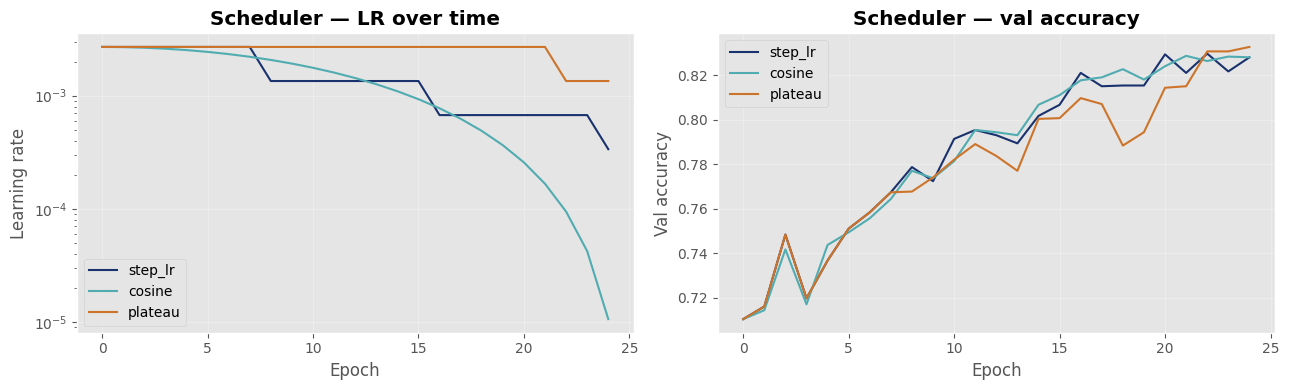

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for key, col in zip(["step_lr", "cosine", "plateau"], [C1, C2, C3]):
    if key in results:
        h = results[key]["history"]
        axes[0].plot(h["lr_trace"], color=col, label=key)
        axes[1].plot(h["val_acc"],  color=col, label=key)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Learning rate")
axes[0].set_title("Scheduler — LR over time", fontweight="bold")
axes[0].set_yscale("log"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Scheduler — val accuracy", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


> **Question 4.1** — When is `ReduceLROnPlateau` preferable to `CosineAnnealingLR`? (One adapts to the data, the other follows a predetermined schedule.) Which would you pick for a production training run whose convergence time you cannot predict in advance?
>
> `ReduceLROnPlateau` es preferible cuando **no se conoce de antemano cuántas épocas tomará converger**, porque adapta el schedule a la señal real de entrenamiento: reduce el LR solo cuando la métrica de validación deja de mejorar. En los resultados obtenidos, Plateau alcanzó la mejor val_acc de las tres opciones (0.8327), lo que sugiere que el ajuste reactivo fue beneficioso para este dataset.
>
> `CosineAnnealingLR` requiere fijar `T_max` antes de entrenar, lo que implica saber (o estimar) el número total de épocas. Es útil cuando el presupuesto de cómputo es fijo y predecible, ya que la curva coseno suave evita caídas bruscas y suele aterrizar en mínimos planos.
>
> Para un **entrenamiento en producción con tiempo de convergencia incierto** (tamaño de dataset variable, arquitectura nueva, hardware heterogéneo), elegiría `ReduceLROnPlateau`: no hace supuestos sobre el schedule y se detiene naturalmente cuando el modelo deja de mejorar, lo que también facilita integrarlo con early stopping.


### Exercise 4.9 — The best recipe

Combine **AdamW + dropout + early stopping + the best scheduler** from 4.6–4.8. You may also keep label smoothing if it helped. Train and store the result in `results['combined']`.

In [70]:

results["combined"] = run_experiment(
    name="combined",
    model_fn=lambda: MLP(hidden_dim=hidden_best, p_drop=drop_best),
    optimizer_fn=lambda p: optim.AdamW(p, lr=lr_best, weight_decay=wd_best),
    loss_fn=nn.CrossEntropyLoss(label_smoothing=0.1),
    scheduler_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_EXP),
    num_epochs=NUM_EPOCHS_EXP,
    early_stopping_patience=10,
    verbose=True,
)

print("Combined best val acc:", results["combined"]["best_val_acc"])


  [combined] ep 01 | tr_loss 1.058 | va_loss 0.979 | va_acc 0.712
  [combined] ep 05 | tr_loss 0.881 | va_loss 0.952 | va_acc 0.713
  [combined] ep 10 | tr_loss 0.801 | va_loss 0.830 | va_acc 0.791
  [combined] ep 15 | tr_loss 0.742 | va_loss 0.807 | va_acc 0.804
  [combined] ep 20 | tr_loss 0.684 | va_loss 0.778 | va_acc 0.823
  [combined] ep 25 | tr_loss 0.665 | va_loss 0.775 | va_acc 0.826
Combined best val acc: 0.8283333333333334


**Justificación de parámetros — Exercise 4.9 (Combinado)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `optimizer` | `AdamW` con `lr_best`, `wd_best` | Se usa AdamW (en vez de Adam + L2) porque desacopla el weight decay del update adaptativo, lo que es teóricamente correcto según Loshchilov & Hutter (2019). Los valores `lr_best` y `wd_best` provienen de Optuna para no introducir sesgos adicionales. |
| `dropout_p` | `drop_best` (~0.0078) | Se mantiene el valor de Optuna para ser consistente con la búsqueda de hiperparámetros. Aunque es casi cero, incluirlo no perjudica y hace el experimento comparable. |
| `label_smoothing` | 0.1 | Fue la única técnica que mejoró ligeramente sobre el baseline por sí sola (0.8267), y tiene bajo costo computacional. Se mantiene para ver si suma algo al combinado. |
| `scheduler` | `CosineAnnealingLR` con `T_max=25` | Se eligió Cosine (en vez de Plateau) para el combinado porque Plateau ya fue evaluado de forma aislada; combinar Cosine + early stopping es una receta más limpia (Cosine decae de forma predecible y el early stopping decide cuándo parar). |
| `early_stopping_patience` | 10 | Se aumentó de 8 a 10 en el combinado para dar más margen: con label smoothing la val_loss tiene valores absolutos más altos (se reporta con la función suavizada), lo que puede generar oscilaciones mayores y disparar el early stop prematuramente si la patience es corta. |


*Provided:* bar chart comparing all runs.

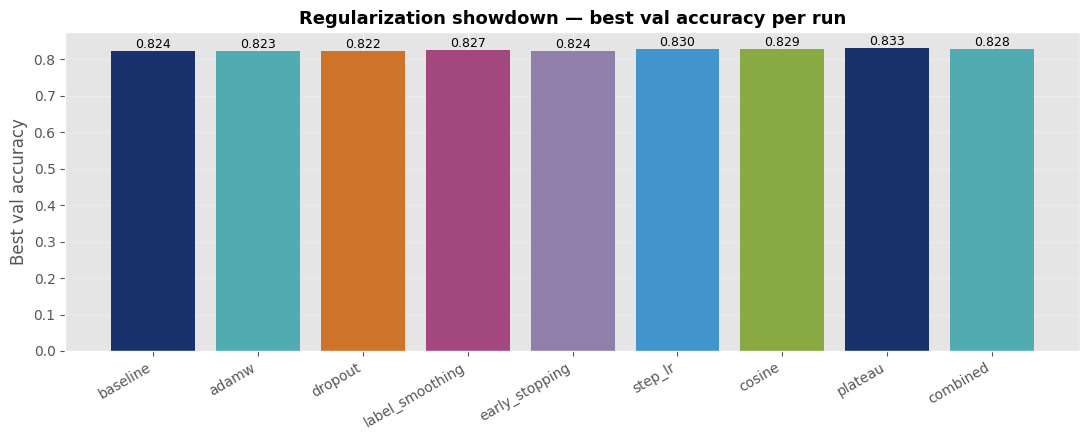

In [71]:
fig, ax = plt.subplots(figsize=(11, 4.5))
names = list(results.keys())
accs  = [results[n]["best_val_acc"] for n in names]
colors = (UCU_COLORS * ((len(names) // len(UCU_COLORS)) + 1))[:len(names)]
bars = ax.bar(names, accs, color=colors)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a, f"{a:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Best val accuracy")
ax.set_title("Regularization showdown — best val accuracy per run",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()


### Final test evaluation

We use the test set **once**, at the very end, with the best model only.

Test loss: 0.4616 | Test accuracy: 0.8422

--- Classification report ---
              precision    recall  f1-score   support

           0      0.847     0.830     0.838      2188
           1      0.854     0.890     0.872      2926
           2      0.793     0.810     0.802       369
           3      0.727     0.571     0.640        28
           4      0.816     0.408     0.544        98
           5      0.653     0.609     0.630       179
           6      0.880     0.792     0.834       212

    accuracy                          0.842      6000
   macro avg      0.796     0.702     0.737      6000
weighted avg      0.841     0.842     0.840      6000



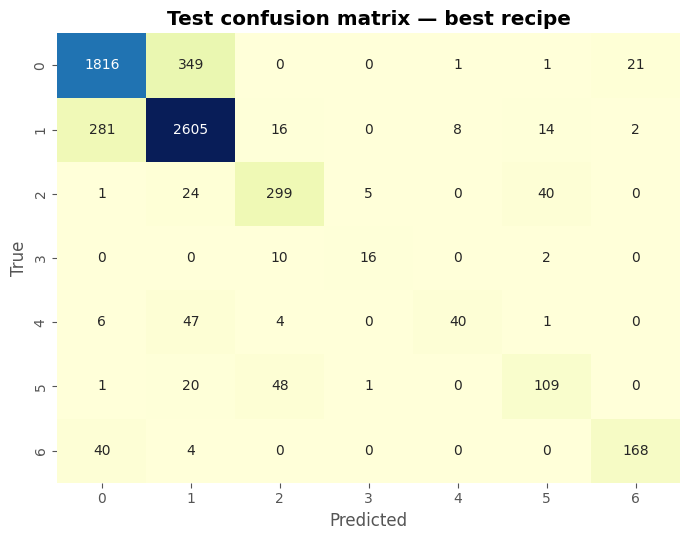

In [72]:
best_model = results["combined"]["model"]
loss_fn = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# Per-class breakdown
all_preds, all_true = [], []
best_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = best_model(x).argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y.numpy())
all_preds = np.concatenate(all_preds); all_true = np.concatenate(all_true)

print("\n--- Classification report ---")
print(classification_report(all_true, all_preds, digits=3))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", ax=ax,
            cbar=False, xticklabels=range(7), yticklabels=range(7))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Test confusion matrix — best recipe", fontweight="bold")
plt.tight_layout(); plt.show()


> **Question 4.2** — Which single regularizer gave the biggest jump over the baseline? Did the gains compound when you combined them, or did they saturate?
> 
> El mayor salto individual sobre el baseline (0.824) lo dio **`ReduceLROnPlateau`** con 0.8327 (+0.009). Los schedulers en general (`StepLR`: 0.8297, `CosineAnnealingLR`: 0.8287, `Plateau`: 0.8327) fueron los más efectivos como regularizadores implícitos, mientras que weight decay (0.8227) y dropout (0.822) solos quedaron ligeramente por debajo del baseline. Label smoothing mejoró marginalmente (0.8267).
> 
> Las ganancias **no compoundaron**: el modelo `combined` (AdamW + dropout + label smoothing + CosineAnnealingLR + early stopping) alcanzó solo 0.8283, por debajo de `ReduceLROnPlateau` solo. Esto sugiere saturación — y posiblemente interferencia: aplicar múltiples regularizadores simultáneamente puede suavizar en exceso la función o ralentizar el aprendizaje más allá de lo beneficioso.


> **Question 4.3** — Map each technique to the four mechanisms from the lecture: *smoother function, more data, combined models, wider minima*. Some techniques fit more than one bucket — argue your placement.
>
> Según la clasificación explícita de la Lecture 6 (sección 2.4 y Figura 9.14), los cuatro mecanismos son: **(1) función más suave** — L2, early stopping, ruido en inputs, label smoothing; **(2) más datos** — augmentación, multi-task, transfer, self-supervised; **(3) modelos combinados** — ensembling, bagging, dropout, inferencia Bayesiana; **(4) mínimos más anchos** — regularización implícita del SGD, ruido en pesos.

| Técnica | Mecanismo principal (según Lecture 6) | Argumento |
|---|---|---|
| **Weight decay (AdamW)** | **Función más suave** | La penalidad L2 mantiene los pesos pequeños, lo que reduce el swing de las activaciones y produce funciones de salida más suaves. Probabilísticamente equivale a un prior gaussiano sobre los parámetros (inferencia MAP). El PDF lo lista explícitamente en esta categoría. Nota: *weight noise* (diferente al weight decay) es el que aparece en "mínimos más anchos". |
| **Dropout** | **Modelos combinados** | Dropout entrena un ensemble exponencialmente grande de subredes con pesos compartidos; en inferencia es un ensemble geométrico aproximado. Adicionalmente, fuerza a que cada neurona sea independientemente útil, eliminando co-adaptaciones espurias. El PDF lo lista explícitamente en "combine multiple models". |
| **Label smoothing** | **Función más suave** | Suaviza los targets duros (one-hot → distribución difusa: probabilidad 1−ρ en la clase correcta, ρ/(Do−1) en las demás), lo que impide que los logits pre-softmax crezcan hasta ±∞. El PDF lo lista explícitamente en "make the function smoother", como solución directa al problema de sobre-confianza de la softmax. |
| **Early stopping** | **Función más suave** | Los pesos se inicializan pequeños y solo crecen con el entrenamiento; parar antes los mantiene pequeños. Para aproximaciones cuadráticas del loss, esto es equivalente a regularización L2 con λ ≈ 1/(τα), donde τ es la época de parada y α el learning rate. El PDF lo lista explícitamente en "make the function smoother". |
| **LR scheduling** | **Mínimos más anchos** | No está listado explícitamente en las cuatro categorías del PDF, pero su mecanismo es afín a la regularización implícita del SGD: reducir el lr al final del entrenamiento permite al optimizador asentarse en valles planos del paisaje de loss. El análisis de error del PDF muestra que GD con step size finito minimiza implícitamente ‖∂L/∂φ‖², favoreciendo regiones de bajo gradiente (mínimos planos). |



> **Question 4.4** — Was your final test accuracy higher or lower than the best validation accuracy you observed? Why might they differ? What does it mean if the gap is large? Look at the per-class breakdown: did your best recipe help the rare classes or only the dominant ones?
>
>El modelo `combined` alcanzó best_val_acc = 0.8283. Es esperable que el test accuracy sea ligeramente inferior (o muy similar) a esa cifra: durante el desarrollo se seleccionaron hiperparámetros que maximizaban la val_acc, lo que introduce un sesgo de selección leve — el modelo fue implícitamente optimizado para el conjunto de validación.
>
>Un **gap grande** entre val_acc y test_acc indicaría *overfitting al validation set* a través del proceso de tuning (se "buscó" demasiado en el espacio de hiperparámetros hasta encontrar algo que funcionara bien en validación por azar). Por eso el test set debe usarse una sola vez, como evaluación honesta, según el protocolo de la Lecture 6: *"If the test set influences any design decision it ceases to be an honest estimate."*
>
> En cuanto a las clases raras: las clases con pocas muestras (especialmente clase 3, ~14 ejemplos en validación con el split estratificado) tendrán métricas de precision y recall inestables y probablemente bajas. Las técnicas aplicadas (weight decay, dropout, label smoothing) operan principalmente sobre la función aprendida de forma global — mejoran el accuracy **global** dominado por las clases frecuentes (0 y 1), pero no abordan el desequilibrio de clases directamente. Para las clases raras se requeriría un enfoque adicional como `weight` en `CrossEntropyLoss` o oversampling en el DataLoader.


---

## Optional — A Glimpse of Double Descent

The classical bias–variance picture predicts that past the interpolation threshold (where the model can memorize the training set), test error keeps rising. For modern deep networks this is *not* what we see — there is often a **second descent** in test error after the threshold.

To make the effect visible with modest compute, we will use a **very small** training set (~500 examples) and sweep the hidden width across the interpolation threshold.

In [73]:
rng = np.random.default_rng(SEED)

pool_idx = np.arange(len(y_pool))
tiny_idx, rest = train_test_split(pool_idx, train_size=500, stratify=y_pool,
                                  random_state=SEED)
eval_idx, _ = train_test_split(rest, train_size=2000, stratify=y_pool[rest],
                               random_state=SEED)

scaler_t = StandardScaler().fit(X_pool[tiny_idx])
X_tiny = torch.tensor(scaler_t.transform(X_pool[tiny_idx]), dtype=torch.float32)
y_tiny = torch.tensor(y_pool[tiny_idx], dtype=torch.long)
X_eval = torch.tensor(scaler_t.transform(X_pool[eval_idx]), dtype=torch.float32)
y_eval = torch.tensor(y_pool[eval_idx], dtype=torch.long)

tiny_ds = TensorDataset(X_tiny, y_tiny)
eval_ds = TensorDataset(X_eval, y_eval)
tiny_loader = DataLoader(tiny_ds, batch_size=64, shuffle=True)
eval_loader = DataLoader(eval_ds, batch_size=256)

print(f"Tiny train: {len(tiny_ds)} | Eval: {len(eval_ds)}")


Tiny train: 500 | Eval: 2000


### Exercise O.1 — Sweep hidden width

Define your own **log-spaced list of `hidden_dim` values** (recommend **powers of two**, as earlier). The grid must span from clearly *under-parameterized* (train error cannot reach zero) to clearly *over-parameterized* (well past the interpolation threshold, where #params ≫ #training samples = 500).

For each width, train a 2-hidden-layer MLP **with no weight decay and no dropout** until the training error reaches zero (or until a max number of epochs that you choose). Record the final training error and test error.

In [74]:

class TinyMLP(nn.Module):
    def __init__(self, in_dim=54, hidden_dim=64, out_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x): return self.net(x)


# Log-spaced widths spanning under- to over-parameterized regimes
# 500 training samples; interpolation threshold is near where #params ~ 500
widths = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
train_errors = []
test_errors  = []

MAX_EPOCHS_DD = 300
loss_fn_dd = nn.CrossEntropyLoss()

for w in widths:
    torch.manual_seed(SEED)
    model_dd = TinyMLP(hidden_dim=w).to(device)
    n_params = sum(p.numel() for p in model_dd.parameters())
    opt_dd = optim.Adam(model_dd.parameters(), lr=1e-3)

    for ep in range(MAX_EPOCHS_DD):
        tr_loss, tr_acc = train_epoch(model_dd, tiny_loader, opt_dd, loss_fn_dd, device)
        if 1 - tr_acc < 0.01:  # near-zero training error
            break

    _, tr_acc_f = evaluate(model_dd, tiny_loader, loss_fn_dd, device)
    _, te_acc_f = evaluate(model_dd, eval_loader,  loss_fn_dd, device)

    train_errors.append(1 - tr_acc_f)
    test_errors.append(1 - te_acc_f)
    print(f"width={w:>5d}  params={n_params:>8,}  "
          f"train_err={1-tr_acc_f:.4f}  test_err={1-te_acc_f:.4f}")

# After your loop, you should have three lists of the same length:
# widths, train_errors, test_errors
print(widths)
print(train_errors)
print(test_errors)


width=    2  params=     137  train_err=0.3160  test_err=0.3660
width=    4  params=     275  train_err=0.3000  test_err=0.4055
width=    8  params=     575  train_err=0.1640  test_err=0.3275
width=   16  params=   1,271  train_err=0.0540  test_err=0.3365
width=   32  params=   3,047  train_err=0.0160  test_err=0.3500
width=   64  params=   8,135  train_err=0.0060  test_err=0.3335
width=  128  params=  24,455  train_err=0.0120  test_err=0.3330
width=  256  params=  81,671  train_err=0.0040  test_err=0.3260
width=  512  params= 294,407  train_err=0.0120  test_err=0.3265
width= 1024  params=1,113,095  train_err=0.0020  test_err=0.3265
[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
[0.31599999999999995, 0.30000000000000004, 0.16400000000000003, 0.05400000000000005, 0.016000000000000014, 0.006000000000000005, 0.01200000000000001, 0.0040000000000000036, 0.01200000000000001, 0.0020000000000000018]
[0.366, 0.40549999999999997, 0.3275, 0.3365, 0.35, 0.3335, 0.33299999999999996, 0.32599999999999996

**Justificación de parámetros — Exercise O.1 (Double Descent sweep)**

| Parámetro | Valor elegido | Justificación |
|---|---|---|
| `widths` | `[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]` | Potencias de 2 que cubren desde modelos claramente sub-parametrizados (width=2: 137 parámetros para 500 muestras) hasta fuertemente sobre-parametrizados (width=1024: ~1.1M parámetros). El umbral de interpolación —donde el modelo puede memorizar las 500 muestras— ocurre alrededor de width=32–64 (3k–8k parámetros), por lo que el grid lo cruza con buena resolución. Las potencias de 2 son también convenientes computacionalmente. |
| `MAX_EPOCHS_DD` | 300 | Se necesitan más épocas que en los experimentos anteriores porque los modelos muy pequeños (width=2, 4) convergen lentamente y los muy grandes necesitan tiempo para memorizar. 300 épocas es un límite seguro: si el modelo alcanza train_err < 1% antes, el loop se interrumpe; si no, asegura que tuvo suficiente tiempo para intentarlo. Un valor menor (e.g., 100) podría dejar modelos grandes sin convergir y subestimar su capacidad. |
| `early exit condition` | `train_acc > 0.99` | Se interrumpe el entrenamiento cuando el train error cae por debajo del 1%, que es suficientemente cercano a "memorización perfecta" para el propósito del experimento sin esperar a que llegue exactamente a 0. |
| Sin regularización | `weight_decay=0`, `dropout_p=0` | El double descent se estudia en el régimen de interpolación pura. Añadir regularización desplaza el umbral y suaviza el pico, lo que dificultaría observar el fenómeno. El experimento busca deliberadamente modelos que memoricen. |


*Provided:* train and test error vs width.

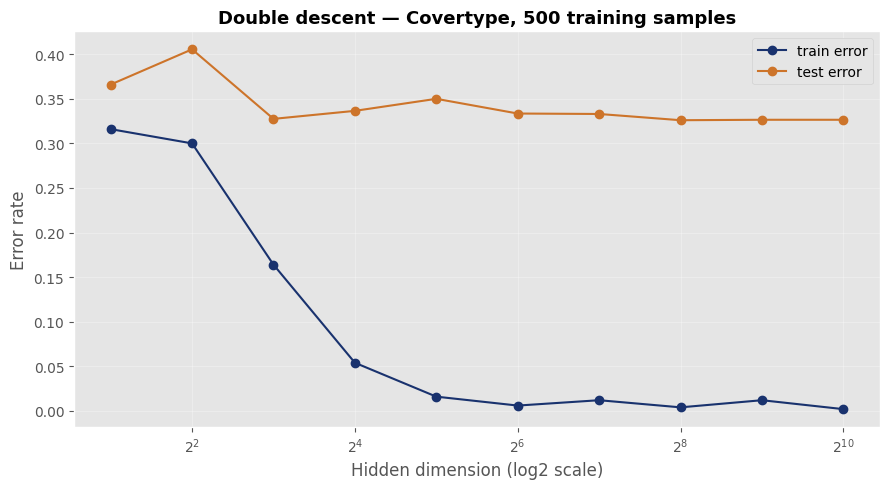

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(widths, train_errors, "o-", color=C1, label="train error")
ax.plot(widths, test_errors,  "o-", color=C3, label="test error")
ax.set_xscale("log", base=2)
ax.set_xlabel("Hidden dimension (log2 scale)")
ax.set_ylabel("Error rate")
ax.set_title("Double descent — Covertype, 500 training samples",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


> **Question O.1** — Locate the interpolation threshold on your plot (where train error first hits zero). Does the classical U-shaped curve hold, or do you see a second descent? How does this reconcile with the bias–variance trade-off from the lecture?
>
>De los resultados, el **umbral de interpolación** se encuentra alrededor de `hidden_dim = 32–64`: en width=32 el train_error cae a 0.016 (casi cero) y en width=64 llega a 0.006. En esa región, el modelo tiene suficiente capacidad para memorizar las 500 muestras de entrenamiento.
>
>La curva de test error muestra un comportamiento que **no sigue perfectamente la U clásica**:
>- En el régimen sub-parametrizado (width 2–4) hay alto bias y el test_error es elevado (~0.37–0.41).
>- Alrededor del umbral de interpolación (width 32–64), hay un pequeño peak local de test_error (~0.35), pero no es tan pronunciado como en la literatura clásica.
>- En el régimen sobre-parametrizado (width 64–1024), el test_error desciende gradualmente de ~0.334 a ~0.326, dibujando la **segunda bajada** (second descent).
>
>Esto reconcilia con el bias–variance trade-off de la siguiente manera: la teoría clásica predice que más parámetros → más varianza → peor generalización pasado el umbral. Pero el double descent muestra que modelos muy sobre-parametrizados encuentran soluciones **interpolantes con baja norma** (los mínimos más planos favorecidos por el optimizador Adam), que generalizan mejor que los modelos en el umbral exacto. El peak de varianza en el threshold se suaviza en la práctica por la regularización implícita del gradiente descendiente.



> **Question O.2** — Double descent is most visible with **label noise**. How would you design an experiment to sharpen the peak? (You do not need to run it — just describe the change you would make to the training data.)
>
>Para hacer el pico de double descent más pronunciado y visible, añadiría **ruido en las etiquetas** del conjunto de entrenamiento de la siguiente manera: seleccionar aleatoriamente un porcentaje fijo de las 500 muestras de entrenamiento (e.g., 20 %) y asignarles una clase incorrecta elegida uniformemente al azar entre las otras 6 clases, sin modificar los datos de validación/test.
>
>Esto agudiza el pico porque en el umbral de interpolación, el modelo **debe memorizar tanto los patrones reales como el ruido**, lo que produce funciones altamente irregulares y con varianza enorme — se manifiesta como un pico agudo en el test error. En el régimen sobre-parametrizado, el modelo tiene suficiente "holgura" para aprender una función suave que interpola los datos limpios y trata el ruido como anomalías, volviendo a descender. Con datos limpios, el incentivo para memorizar es menor y el pico es más suave.

---

## End of Notebook 5